<a href="https://colab.research.google.com/github/Victor-Tung/CS123a_AM1_term_project/blob/main/Gene_counting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mount Drive + set paths

In [2]:
from google.colab import drive
drive.mount('/content/drive')

folder = "/content/drive/MyDrive/123a_term_project"

# Reference genome
ref = f"{folder}/GCF_000022685.1_ASM2268v1_genomic.fna"

# BAM files (already aligned)
evo_bam = f"{folder}/evoHLn.bam"
bam_5642 = f"{folder}/5642_1.bam"

# FASTQ (optional if you re-align)
fastq_5642 = f"{folder}/5642_1_S37_R1_001.fastq.gz"

# OUTPUT
output_dir = "/content/project_outputs"
!mkdir -p {output_dir}

Mounted at /content/drive


Tools Installation

In [4]:
!apt-get update -qq
!apt-get install -y hisat2 samtools subread
!pip install pysam pandas numpy seaborn matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  bcftools libhts3 libhtscodecs2 python3-hisat2
Suggested packages:
  python3-numpy python3-matplotlib texlive-latex-recommended cwltool
The following NEW packages will be installed:
  bcftools hisat2 libhts3 libhtscodecs2 python3-hisat2 samtools subread
0 upgraded, 7 newly installed, 0 to remove and 75 not upgraded.
Need to get 6,069 kB of archives.
After this operation, 19.0 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libhtscodecs2 amd64 1.1.1-3 [53.2 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libhts3 amd64 1.13+ds-2build1 [390 kB]
Get:3 http://archive.ubuntu.com/ubuntu jam

Download GFF annotation (helps read gene-level counting)

In [5]:
!wget -P {folder} https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/022/685/GCF_000022685.1_ASM2268v1/GCF_000022685.1_ASM2268v1_genomic.gff.gz

--2026-05-06 00:27:50--  https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/022/685/GCF_000022685.1_ASM2268v1/GCF_000022685.1_ASM2268v1_genomic.gff.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.12, 130.14.250.13, 2607:f220:41e:250::12, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.12|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 526935 (515K) [application/x-gzip]
Saving to: ‘/content/drive/MyDrive/123a_term_project/GCF_000022685.1_ASM2268v1_genomic.gff.gz’

GCF_000022685.1_ASM 100%[===================>] 514.58K  --.-KB/s    in 0.06s   

2026-05-06 00:27:50 (8.15 MB/s) - ‘/content/drive/MyDrive/123a_term_project/GCF_000022685.1_ASM2268v1_genomic.gff.gz’ saved [526935/526935]



In [6]:
!gunzip {folder}/GCF_000022685.1_ASM2268v1_genomic.gff.gz

In [7]:
!ls {folder}

 5642_1.bam			       gantc_heatmap_evohln.png
 5642_1.bam.bai			       gantc_heatmap_evohln_vmax20.png
 5642_1_S37_R1_001.fastq.gz	       gantc_heatmap_normalized.png
 CS123a_project.ipynb		       gantc_heatmap.png
 CS123a_project_presentation.gslides   GCF_000022685.1_ASM2268v1_genomic.fna
'cs 123a project proposal.gdoc'        GCF_000022685.1_ASM2268v1_genomic.gff
 CS123a_project_report.gdoc	       genomic.gff
 evoHLn.bam			       SRR17468317_1.fastq
 evoHLn.bam.bai			       SRR17468317_2.fastq
 gantc_heatmap_all_evohln.png	       Testing.ipynb


In [8]:
annotation = f"{folder}/GCF_000022685.1_ASM2268v1_genomic.gff"

Confirmed annotation file has been added

In [9]:
import os
print(os.path.exists(annotation))

True


Parse Genes

In [10]:
import pandas as pd
import re

def parse_gff_genes(gff_file):
    """
    Parse a GFF file to extract gene-level annotations.

    Parameters
    ----------
    gff_file : str
        Path to the GFF annotation file.

    Returns
    -------
    pandas.DataFrame
        A DataFrame containing gene annotations with columns:
        - chrom   : chromosome/contig name
        - start   : gene start position (0-based)
        - end     : gene end position (1-based, GFF standard)
        - gene_id : locus tag or fallback identifier
    """

    genes = []  # List to store gene annotation dictionaries

    # Open and read the GFF file line by line
    with open(gff_file, "r") as f:
        for line in f:

            # Skip comment/header lines
            if line.startswith("#"):
                continue

            # Split line into GFF fields (should be 9 columns)
            parts = line.strip().split("\t")
            if len(parts) != 9:
                continue  # Skip malformed lines

            chrom, _, feature, start, end, _, strand, _, attributes = parts

            # Only keep entries annotated as "gene"
            if feature != "gene":
                continue

            # Extract locus_tag from attributes field using regex
            match = re.search(r"locus_tag=([^;]+)", attributes)
            if match:
                gene_id = match.group(1)
            else:
                # Fallback ID if locus_tag is missing
                gene_id = f"{chrom}_{start}_{end}"

            # Append gene information to list
            genes.append({
                "chrom": chrom,
                "start": int(start) - 1,  # Convert to 0-based indexing
                "end": int(end),          # End remains 1-based
                "gene_id": gene_id
            })

    # Convert list of dictionaries into a pandas DataFrame
    return pd.DataFrame(genes)


# Run parser on annotation file
genes_df = parse_gff_genes(annotation)

# Preview first few rows
genes_df.head()

,chrom,start,end,gene_id
0,NC_012808.1,711,2217,MEXAM1_RS00005
1,NC_012808.1,2539,3661,MEXAM1_RS00010
2,NC_012808.1,3701,4859,MEXAM1_RS00015
3,NC_012808.1,4866,5481,MEXAM1_RS00020
4,NC_012808.1,5771,7619,MEXAM1_RS00025


Run Alg

In [11]:
import pysam
from collections import defaultdict
import pandas as pd

def count_reads_per_gene(bam_file, genes_df):
    """
    Count the number of reads overlapping each gene from a BAM file.

    Parameters
    ----------
    bam_file : str
        Path to the BAM alignment file (must be indexed).
    genes_df : pandas.DataFrame
        DataFrame containing gene annotations with columns:
        - chrom   : chromosome/contig name
        - start   : gene start position (0-based)
        - end     : gene end position (1-based)
        - gene_id : gene identifier

    Returns
    -------
    pandas.DataFrame
        A DataFrame with:
        - gene_id : gene identifier
        - count   : number of reads overlapping the gene
    """

    # Open BAM file in read-binary mode
    bam = pysam.AlignmentFile(bam_file, "rb")

    # Dictionary to store read counts per gene
    counts = defaultdict(int)

    # Iterate through each gene in the annotation table
    for _, gene in genes_df.iterrows():
        chrom = gene["chrom"]

        # Skip genes whose chromosome is not present in the BAM file
        if chrom not in bam.references:
            continue

        # Fetch reads overlapping the gene region
        for read in bam.fetch(chrom, gene["start"], gene["end"]):

            # Exclude unmapped reads
            if not read.is_unmapped:
                counts[gene["gene_id"]] += 1

    # Close BAM file
    bam.close()

    # Convert counts dictionary to DataFrame
    return pd.DataFrame({
        "gene_id": list(counts.keys()),
        "count": list(counts.values())
    })


# Count reads for each strain
evo_counts = count_reads_per_gene(evo_bam, genes_df)
dsr_counts = count_reads_per_gene(bam_5642, genes_df)

In [12]:
evo_bam = "/content/drive/MyDrive/123a_term_project/evoHLn.bam"

import os
print(os.path.exists(evo_bam))

True


Verifying files

In [13]:
# Check that all required files exist before starting analysis

import os

evo_bam = f"{folder}/evoHLn.bam"
bam_5642 = f"{folder}/5642_1.bam"

print("evoHLn BAM exists:", os.path.exists(evo_bam))
print("5642 BAM exists:", os.path.exists(bam_5642))
print("Annotation exists:", os.path.exists(annotation))

evoHLn BAM exists: True
5642 BAM exists: True
Annotation exists: True


Index BAM files

In [15]:
# featureCounts counts how many RNA-seq read pairs overlap each gene.
# We use -p because the BAM files contain paired-end reads.

fc_output = f"{output_dir}/gene_counts.txt"

!featureCounts \
  -p \
  -a {annotation} \
  -o {fc_output} \
  -t gene \
  -g locus_tag \
  {evo_bam} {bam_5642}


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.0.3

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 2 BAM files                                      ||
||                                                                            ||
||                           evoHLn.bam                                       ||
||                           5642_1.bam                                       ||
||                                                               

In [16]:
# Check why reads were or were not assigned

summary_file = f"{fc_output}.summary"

summary = pd.read_csv(summary_file, sep="\t")
summary

,Status,/content/drive/MyDrive/123a_term_project/evoHLn.bam,/content/drive/MyDrive/123a_term_project/5642_1.bam
0,Assigned,12114415,0
1,Unassigned_Unmapped,272961,1122220
2,Unassigned_Read_Type,0,0
3,Unassigned_Singleton,0,0
4,Unassigned_MappingQuality,0,0
5,Unassigned_Chimera,0,0
6,Unassigned_FragmentLength,0,0
7,Unassigned_Duplicate,0,0
8,Unassigned_MultiMapping,86032163,14803216
9,Unassigned_Secondary,0,0


In [17]:
# Compare chromosome/contig names inside each BAM file

import pysam

def show_bam_references(bam_path):
    bam = pysam.AlignmentFile(bam_path, "rb")
    refs = list(bam.references)
    bam.close()
    return refs

evo_refs = show_bam_references(evo_bam)
refs_5642 = show_bam_references(bam_5642)

print("evoHLn references:")
print(evo_refs)

print("\n5642 references:")
print(refs_5642)

evoHLn references:
['NC_012808.1', 'NC_012811.1', 'NC_012807.1', 'NC_012809.1', 'NC_012810.1']

5642 references:
['CP001510.1', 'CP001511.1', 'CP001512.1', 'CP001513.1', 'CP001514.1']


In [18]:
# Check chromosome/contig names inside the GFF annotation file

gff_chroms = set()

with open(annotation, "r") as f:
    for line in f:
        if line.startswith("#"):
            continue
        parts = line.strip().split("\t")
        if len(parts) == 9:
            gff_chroms.add(parts[0])

print("GFF chromosomes:")
print(sorted(gff_chroms))

GFF chromosomes:
['NC_012807.1', 'NC_012808.1', 'NC_012809.1', 'NC_012810.1', 'NC_012811.1']


In [19]:
# Load the featureCounts output table

counts = pd.read_csv(fc_output, sep="\t", comment="#")
counts.head()

,Geneid,Chr,Start,End,Strand,Length,/content/drive/MyDrive/123a_term_project/evoHLn.bam,/content/drive/MyDrive/123a_term_project/5642_1.bam
0,MEXAM1_RS00005,NC_012808.1,712,2217,+,1506,6447,0
1,MEXAM1_RS00010,NC_012808.1,2540,3661,+,1122,5548,0
2,MEXAM1_RS00015,NC_012808.1,3702,4859,+,1158,824,0
3,MEXAM1_RS00020,NC_012808.1,4867,5481,+,615,218,0
4,MEXAM1_RS00025,NC_012808.1,5772,7619,+,1848,962,0


In [20]:
# Clean featureCounts output into a simple table

counts_clean = counts[["Geneid", evo_bam, bam_5642]].copy()

counts_clean = counts_clean.rename(columns={
    "Geneid": "gene_id",
    evo_bam: "evoHLn_count",
    bam_5642: "5642_count"
})

counts_clean.head()

,gene_id,evoHLn_count,5642_count
0,MEXAM1_RS00005,6447,0
1,MEXAM1_RS00010,5548,0
2,MEXAM1_RS00015,824,0
3,MEXAM1_RS00020,218,0
4,MEXAM1_RS00025,962,0


In [21]:
print("Total evoHLn counts:", counts_clean["evoHLn_count"].sum())
print("Total 5642 counts:", counts_clean["5642_count"].sum())

counts_clean.describe()

Total evoHLn counts: 12114415
Total 5642 counts: 0


,evoHLn_count,5642_count
count,6339.000000,6339.0
mean,1911.092444,0.0
std,12743.010178,0.0
min,0.000000,0.0
25%,103.000000,0.0
50%,339.000000,0.0
75%,1076.000000,0.0
max,582993.000000,0.0


GFF annotation matches

In [23]:
# Create a copy of the GFF annotation with chromosome names changed
# so they match the 5642 BAM file references.

mapping = {
    "NC_012808.1": "CP001510.1",
    "NC_012811.1": "CP001511.1",
    "NC_012807.1": "CP001512.1",
    "NC_012809.1": "CP001513.1",
    "NC_012810.1": "CP001514.1"
}

annotation_5642 = f"{output_dir}/annotation_5642_fixed.gff"

with open(annotation, "r") as infile, open(annotation_5642, "w") as outfile:
    for line in infile:
        if line.startswith("#"):
            outfile.write(line)
            continue

        parts = line.rstrip("\n").split("\t")

        if len(parts) == 9 and parts[0] in mapping:
            parts[0] = mapping[parts[0]]
            outfile.write("\t".join(parts) + "\n")
        else:
            outfile.write(line)

print("Fixed 5642 annotation saved to:", annotation_5642)

Fixed 5642 annotation saved to: /content/project_outputs/annotation_5642_fixed.gff


Count each BAM separately

In [24]:
# Count evoHLn using original annotation
fc_evo = f"{output_dir}/gene_counts_evoHLn.txt"

!featureCounts \
  -p \
  -a {annotation} \
  -o {fc_evo} \
  -t gene \
  -g locus_tag \
  {evo_bam}


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.0.3

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 1 BAM file                                       ||
||                                                                            ||
||                           evoHLn.bam                                       ||
||                                                                            ||
||             Output file : gene_counts_evoHLn.txt              

In [25]:
# Count 5642 using fixed annotation
fc_5642 = f"{output_dir}/gene_counts_5642.txt"

!featureCounts \
  -p \
  -a {annotation_5642} \
  -o {fc_5642} \
  -t gene \
  -g locus_tag \
  {bam_5642}


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.0.3

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 1 BAM file                                       ||
||                                                                            ||
||                           5642_1.bam                                       ||
||                                                                            ||
||             Output file : gene_counts_5642.txt                

load and merge counts

In [26]:
import pandas as pd

evo_fc = pd.read_csv(fc_evo, sep="\t", comment="#")
dsr_fc = pd.read_csv(fc_5642, sep="\t", comment="#")

evo_counts = evo_fc[["Geneid", evo_bam]].rename(columns={
    "Geneid": "gene_id",
    evo_bam: "evoHLn_count"
})

dsr_counts = dsr_fc[["Geneid", bam_5642]].rename(columns={
    "Geneid": "gene_id",
    bam_5642: "5642_count"
})

counts_clean = pd.merge(evo_counts, dsr_counts, on="gene_id", how="outer").fillna(0)

counts_clean.head()

,gene_id,evoHLn_count,5642_count
0,MEXAM1_RS00005,6447,6477
1,MEXAM1_RS00010,5548,7941
2,MEXAM1_RS00015,824,699
3,MEXAM1_RS00020,218,521
4,MEXAM1_RS00025,962,1406


Check totals

In [27]:
print("Total evoHLn counts:", counts_clean["evoHLn_count"].sum())
print("Total 5642 counts:", counts_clean["5642_count"].sum())

Total evoHLn counts: 12114415
Total 5642 counts: 23456189


Calculate log2 fold change

In [28]:
# Import NumPy for log2 calculations
import numpy as np

# Make sure count columns are numeric so calculations work correctly
counts_clean["evoHLn_count"] = counts_clean["evoHLn_count"].astype(float)
counts_clean["5642_count"] = counts_clean["5642_count"].astype(float)

# Calculate log2 fold change:
# log2FC > 0 means higher expression in EvoHLn
# log2FC < 0 means higher expression in 5642
# +1 prevents division by zero if a gene has 0 reads
counts_clean["log2FC"] = np.log2(
    (counts_clean["evoHLn_count"] + 1) / (counts_clean["5642_count"] + 1)
)

# Classify genes based on fold-change threshold
# log2FC >= 1 means at least 2x higher in EvoHLn
# log2FC <= -1 means at least 2x lower in EvoHLn
counts_clean["regulation"] = "no major change"
counts_clean.loc[counts_clean["log2FC"] >= 1, "regulation"] = "upregulated in EvoHLn"
counts_clean.loc[counts_clean["log2FC"] <= -1, "regulation"] = "downregulated in EvoHLn"

# Show the top 10 genes with highest expression increase in EvoHLn
counts_clean.sort_values("log2FC", ascending=False).head(10)

,gene_id,evoHLn_count,5642_count,log2FC,regulation
6030,MEXAM1_RS32720,22001.0,1450.0,3.922515,upregulated in EvoHLn
1587,MEXAM1_RS08335,23342.0,1720.0,3.761671,upregulated in EvoHLn
1075,MEXAM1_RS05670,104672.0,9646.0,3.439665,upregulated in EvoHLn
1586,MEXAM1_RS08330,65099.0,6958.0,3.225706,upregulated in EvoHLn
4115,MEXAM1_RS21740,12895.0,1404.0,3.198282,upregulated in EvoHLn
2411,MEXAM1_RS12635,8.0,0.0,3.169925,upregulated in EvoHLn
1585,MEXAM1_RS08325,485104.0,55416.0,3.129897,upregulated in EvoHLn
6261,MEXAM1_RS35015,2963.0,366.0,3.013693,upregulated in EvoHLn
3013,MEXAM1_RS15785,1117.0,141.0,2.976957,upregulated in EvoHLn
370,MEXAM1_RS01945,50199.0,6582.0,2.930870,upregulated in EvoHLn


Summary statstics

In [29]:
# Count how many genes fall into each regulation category

total_genes = len(counts_clean)
upregulated = (counts_clean["log2FC"] >= 1).sum()
downregulated = (counts_clean["log2FC"] <= -1).sum()
no_major_change = ((counts_clean["log2FC"] > -1) & (counts_clean["log2FC"] < 1)).sum()

print("Total genes analyzed:", total_genes)
print("Upregulated in EvoHLn:", upregulated)
print("Downregulated in EvoHLn:", downregulated)
print("No major change:", no_major_change)

Total genes analyzed: 6339
Upregulated in EvoHLn: 90
Downregulated in EvoHLn: 3102
No major change: 3147


Save results table

In [30]:
# Save final gene count and fold-change results as a CSV file
# This file can be included in the project submission or used in the report

results_path = f"{output_dir}/gene_counts_log2FC.csv"

counts_clean.to_csv(results_path, index=False)

print("Saved results to:", results_path)

Saved results to: /content/project_outputs/gene_counts_log2FC.csv


Heatmap of top 30 changed genes

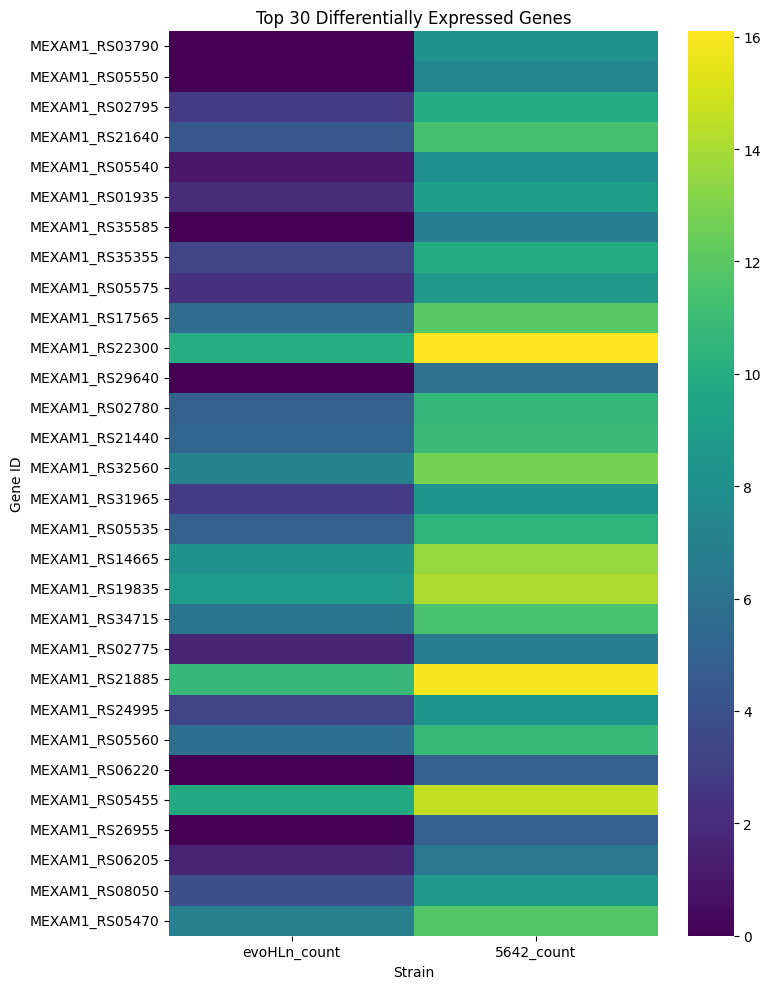

Saved heatmap to: /content/project_outputs/top30_gene_expression_heatmap.png


In [31]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Select the 30 genes with the largest absolute log2 fold change
# These are the genes that changed the most between the two strains
top_genes = counts_clean.reindex(
    counts_clean["log2FC"].abs().sort_values(ascending=False).index
).head(30)

# Prepare count data for the heatmap
# Rows = genes
# Columns = strains
heatmap_data = top_genes.set_index("gene_id")[["evoHLn_count", "5642_count"]]

# Apply log2(count + 1) transformation
# This makes the heatmap easier to read because RNA counts can vary widely
heatmap_data_log = np.log2(heatmap_data + 1)

# Create and save heatmap
plt.figure(figsize=(8, 10))
sns.heatmap(heatmap_data_log, cmap="viridis")
plt.title("Top 30 Differentially Expressed Genes")
plt.xlabel("Strain")
plt.ylabel("Gene ID")
plt.tight_layout()

heatmap_path = f"{output_dir}/top30_gene_expression_heatmap.png"
plt.savefig(heatmap_path, dpi=300)

plt.show()

print("Saved heatmap to:", heatmap_path)

^Interpretation:

What it shows:
This heatmap compares gene expression levels between the EvoHLn and 5642 strains for the 30 genes with the largest differences.

Axes:

Y-axis: Gene IDs (e.g., MEXAM1_RS03790)
X-axis: Strains (evoHLn_count, 5642_count)

What MEXAM1_RSxxxx means:
These are gene identifiers (locus tags) for specific genes in Methylorubrum extorquens. Each one corresponds to a unique gene in the genome.

What the colors mean:

Color intensity represents log2-transformed read counts
Brighter = higher expression
Darker = lower expression

Interpretation:
Most genes show noticeably higher expression in the 5642 strain, suggesting stronger transcription activity for these genes compared to EvoHLn.


Bar plot of top unregulated genes:

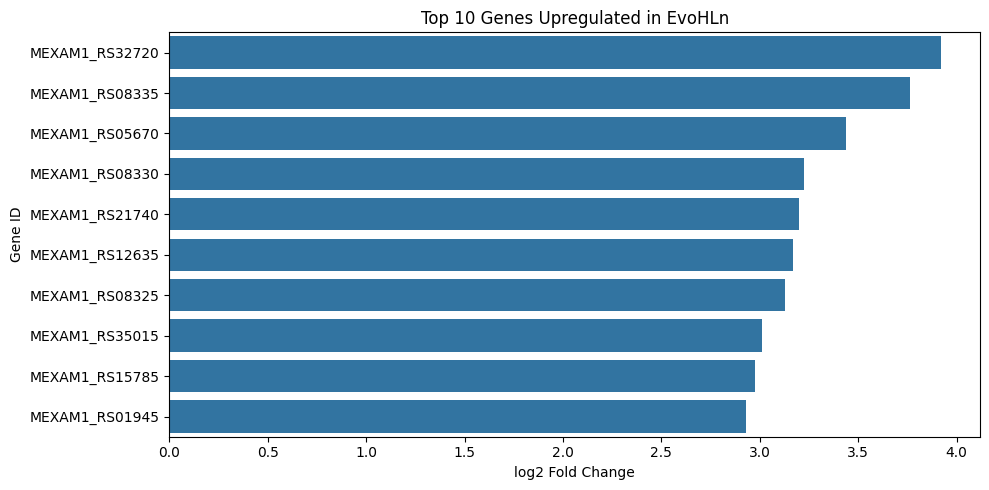

Saved plot to: /content/project_outputs/top10_upregulated_evoHLn.png


In [32]:
# Select the 10 genes with the highest positive log2 fold change
# These genes are most upregulated in EvoHLn compared to 5642
top_up = counts_clean.sort_values("log2FC", ascending=False).head(10)

# Create horizontal bar plot
plt.figure(figsize=(10, 5))
sns.barplot(data=top_up, x="log2FC", y="gene_id")

plt.title("Top 10 Genes Upregulated in EvoHLn")
plt.xlabel("log2 Fold Change")
plt.ylabel("Gene ID")
plt.tight_layout()

up_plot_path = f"{output_dir}/top10_upregulated_evoHLn.png"
plt.savefig(up_plot_path, dpi=300)

plt.show()

print("Saved plot to:", up_plot_path)

^Interpretation:

What it shows:
This bar plot highlights the genes that are most upregulated in EvoHLn compared to 5642.

Axes:

Y-axis: Gene IDs
X-axis: Log2 fold change (expression difference)

What fold change means:

It measures how much gene expression differs between the two strains
Positive values → higher in EvoHLn
Example: log2FC = 3 → ~8× higher expression in EvoHLn

Interpretation:
These genes are significantly more active in EvoHLn, suggesting they may be involved in adaptation or alternative metabolic pathways in this strain.

Bar plot of top downregulated genes

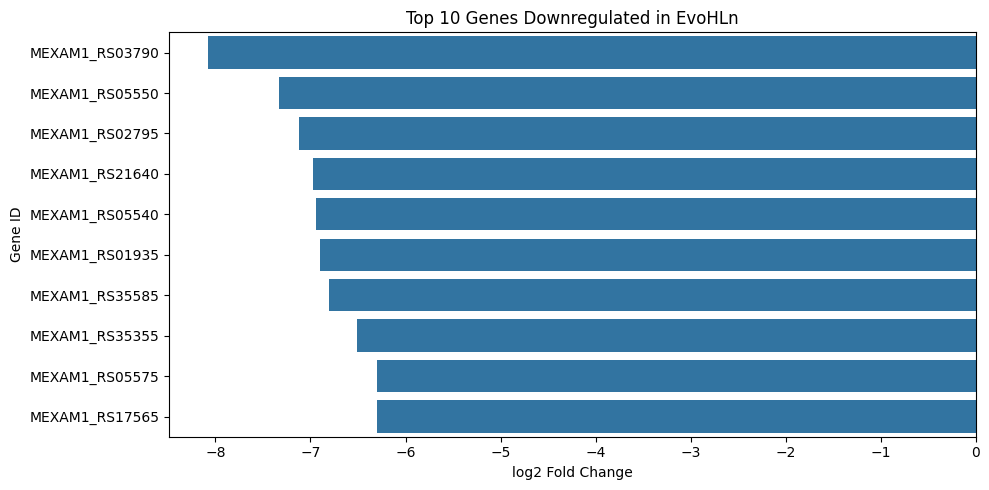

Saved plot to: /content/project_outputs/top10_downregulated_evoHLn.png


In [33]:
# Select the 10 genes with the lowest negative log2 fold change
# These genes are most downregulated in EvoHLn,
# meaning they are more highly expressed in 5642
top_down = counts_clean.sort_values("log2FC", ascending=True).head(10)

# Create horizontal bar plot
plt.figure(figsize=(10, 5))
sns.barplot(data=top_down, x="log2FC", y="gene_id")

plt.title("Top 10 Genes Downregulated in EvoHLn")
plt.xlabel("log2 Fold Change")
plt.ylabel("Gene ID")
plt.tight_layout()

down_plot_path = f"{output_dir}/top10_downregulated_evoHLn.png"
plt.savefig(down_plot_path, dpi=300)

plt.show()

print("Saved plot to:", down_plot_path)

^Interpretation:

What it shows:
This plot shows genes that are downregulated in EvoHLn (i.e., more highly expressed in 5642).

Axes:

Y-axis: Gene IDs
X-axis: Log2 fold change

What fold change means:

Negative values → higher expression in 5642
Example: log2FC = -7 → ~128× higher expression in 5642

Interpretation:
These genes are much more active in the 5642 strain, indicating strong suppression or reduced activity in EvoHLn. This could reflect differences in regulatory pathways or gene usage between the strains.
